<a href="https://colab.research.google.com/github/AdityaChoudhary-max/Machine-learning/blob/main/Machine_Learning_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
uploaded = files.upload()

Saving games.csv to games.csv


In [2]:
import pandas as pd
import numpy as np

In [3]:
df = pd.read_csv("games.csv")
print(df.head())
print(df.columns)

         id  rated    created_at  last_move_at  turns victory_status winner  \
0  TZJHLljE  False  1.504210e+12  1.504210e+12     13      outoftime  white   
1  l1NXvwaE   True  1.504130e+12  1.504130e+12     16         resign  black   
2  mIICvQHh   True  1.504130e+12  1.504130e+12     61           mate  white   
3  kWKvrqYL   True  1.504110e+12  1.504110e+12     61           mate  white   
4  9tXo1AUZ   True  1.504030e+12  1.504030e+12     95           mate  white   

  increment_code       white_id  white_rating      black_id  black_rating  \
0           15+2       bourgris          1500          a-00          1191   
1           5+10           a-00          1322     skinnerua          1261   
2           5+10         ischia          1496          a-00          1500   
3           20+0  daniamurashov          1439  adivanov2009          1454   
4           30+3      nik221107          1523  adivanov2009          1469   

                                               moves opening_e

In [4]:
df = df[['rated', 'turns', 'victory_status', 'winner',
         'white_rating', 'black_rating', 'opening_ply']]

df['rated'] = df['rated'].astype(int)

df = df.drop('victory_status', axis=1)

df['winner'] = df['winner'].map({'white': 0, 'black': 1, 'draw': 2})

df = df.dropna()

print(df.dtypes)

rated           int64
turns           int64
winner          int64
white_rating    int64
black_rating    int64
opening_ply     int64
dtype: object


In [5]:
X = df.drop('winner', axis=1)
y = df['winner']

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [7]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Logistic Regression -   Kavy Khanna

In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

model = LogisticRegression(max_iter=3000, class_weight='balanced')

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [9]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.5299102691924227
Confusion Matrix:
 [[1090  461  453]
 [ 470  932  414]
 [  42   46  104]]


Decision Tree - Abhishek Bora

In [10]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

In [11]:
from sklearn.tree import DecisionTreeClassifier

model_dt = DecisionTreeClassifier(
    random_state=42,
    class_weight='balanced'
)

In [12]:
model_dt.fit(X_train, y_train)

y_pred_dt = model_dt.predict(X_test)

In [13]:
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_dt))

Decision Tree Accuracy: 0.6445663010967099
Confusion Matrix:
 [[1390  540   74]
 [ 567 1166   83]
 [  80   82   30]]


SVM (Support Vector Machine) - Aditya Choudhary

In [14]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix

In [15]:
model_svm = SVC(
    kernel='rbf',
    class_weight='balanced'
)

In [16]:
model_svm.fit(X_train, y_train)

y_pred_svm = model_svm.predict(X_test)

In [17]:
print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_svm))

SVM Accuracy: 0.5294117647058824
Confusion Matrix:
 [[1070  479  455]
 [ 457  936  423]
 [  35   39  118]]


Conclusion

In [18]:
print("\nFinal Comparison:")
print("Logistic Regression:", accuracy_score(y_test, y_pred))
print("Decision Tree:", accuracy_score(y_test, y_pred_dt))
print("SVM:", accuracy_score(y_test, y_pred_svm))


Final Comparison:
Logistic Regression: 0.5299102691924227
Decision Tree: 0.6445663010967099
SVM: 0.5294117647058824


In [19]:
import matplotlib.pyplot as plt

In [20]:
models = ['Logistic', 'Decision Tree', 'SVM']
accuracy = [
    accuracy_score(y_test, y_pred),
    accuracy_score(y_test, y_pred_dt),
    accuracy_score(y_test, y_pred_svm)
]

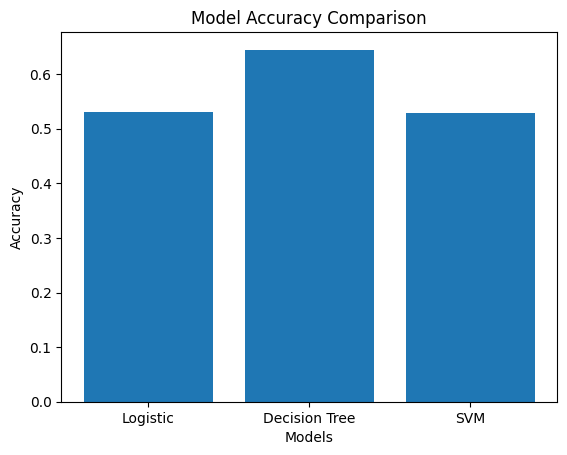

In [21]:
plt.bar(models, accuracy)
plt.title("Model Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.show()

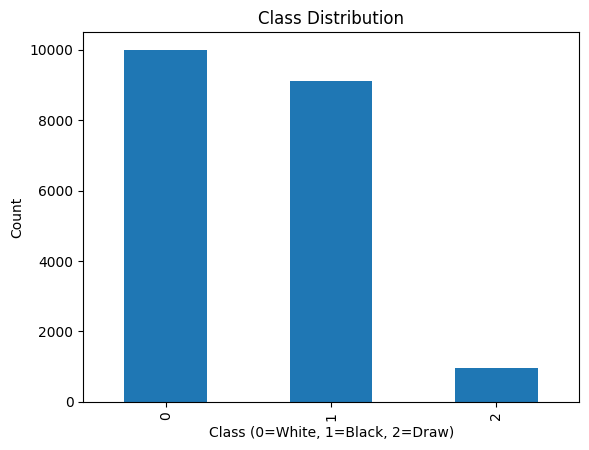

In [22]:
df['winner'].value_counts().plot(kind='bar')
plt.title("Class Distribution")
plt.xlabel("Class (0=White, 1=Black, 2=Draw)")
plt.ylabel("Count")
plt.show()

In [25]:
importance = model_dt.feature_importances_
features = X.columns

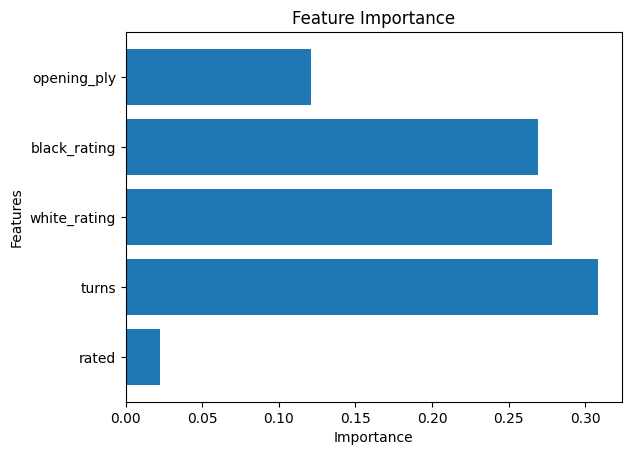

In [26]:
plt.barh(features, importance)
plt.title("Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Features")
plt.show()